experimenting with pipeline and parameters still a lot of overfitting

In [33]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import ADASYN, SMOTE 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd

X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
X_test = pd.read_csv('Datasets/cleaned_X_test2.csv')
y_test = pd.read_csv('Datasets/y_test.csv')

y_train = y_train.idxmax(axis=1)
y_test = y_test.idxmax(axis=1)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

y_train_encoded_series = pd.Series(y_train_encoded)

print("Class distribution in the training set:")
print(y_train_encoded_series.value_counts())


print("Class distribution in the training set:")
print(y_train_encoded.value_counts())

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  
    ('scaler', StandardScaler()),  
    ('oversampler', SMOTE(sampling_strategy=0.5, random_state=42)),  
    # ('oversampler', ADASYN(sampling_strategy=0.5, random_state=42)),  # ADASYN
    ('logreg', LogisticRegressionCV(cv=StratifiedKFold(n_splits=5), max_iter=5000, multi_class='ovr', solver='liblinear', n_jobs=-1, class_weight='balanced')) 
])

param_grid = {
    'logreg__Cs': [0.001, 0.01, 0.1, 1, 10, 100],  
    'logreg__max_iter': [500, 1000, 2000], 
    'logreg__solver': ['liblinear', 'lbfgs', 'saga'], 
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train_encoded)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
print(f"Train Accuracy: {accuracy_score(y_train_encoded, y_train_pred):.3f}")
print("Train Classification Report:")
print(classification_report(y_train_encoded, y_train_pred))

y_test_pred = best_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test_encoded, y_test_pred):.3f}")
print("Test Classification Report:")
print(classification_report(y_test_encoded, y_test_pred))


Class distribution in the training set:
6    62
5    50
0    48
3    48
2    41
4    39
1    37
9    30
8    25
7    24
Name: count, dtype: int64
Class distribution in the training set:


AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

second try

In [32]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
X_test = pd.read_csv('Datasets/cleaned_X_test2.csv')
y_test = pd.read_csv('Datasets/y_test.csv')

y_train = y_train.idxmax(axis=1)
y_test = y_test.idxmax(axis=1)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  
    ('scaler', StandardScaler()), 
    ('oversampler', RandomOverSampler(random_state=42)), 
    ('logreg', LogisticRegressionCV(cv=3, max_iter=1000, multi_class='ovr', solver='liblinear', n_jobs=-1, class_weight='balanced'))  
])

param_grid = {
    'logreg__Cs': [0.1, 1, 10],  
    'logreg__max_iter': [1000], 
    'logreg__solver': ['liblinear'],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train_encoded)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
print(f"Train Accuracy: {accuracy_score(y_train_encoded, y_train_pred):.3f}")
print("Train Classification Report:")
print(classification_report(y_train_encoded, y_train_pred))

y_test_pred = best_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test_encoded, y_test_pred):.3f}")
print("Test Classification Report:")
print(classification_report(y_test_encoded, y_test_pred))


Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END logreg__Cs=0.1, logreg__max_iter=1000, logreg__solver=liblinear; total time=   0.1s
[CV] END logreg__Cs=0.1, logreg__max_iter=1000, logreg__solver=liblinear; total time=   0.1s


/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1917: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1917: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV] END logreg__Cs=0.1, logreg__max_iter=1000, logreg__solver=liblinear; total time=   0.1s


/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1917: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1917: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1917: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_logist

[CV] END logreg__Cs=1, logreg__max_iter=1000, logreg__solver=liblinear; total time=   1.8s
[CV] END logreg__Cs=1, logreg__max_iter=1000, logreg__solver=liblinear; total time=   2.2s
[CV] END logreg__Cs=1, logreg__max_iter=1000, logreg__solver=liblinear; total time=   3.4s
[CV] END logreg__Cs=10, logreg__max_iter=1000, logreg__solver=liblinear; total time=  22.2s
[CV] END logreg__Cs=10, logreg__max_iter=1000, logreg__solver=liblinear; total time=  22.8s
[CV] END logreg__Cs=10, logreg__max_iter=1000, logreg__solver=liblinear; total time=  22.9s


/home/marilene/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3 fits failed out of a total of 9.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/home/marilene/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/marilene/.local/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/marilene/.local/lib/python3.10/site-packages/imblearn/pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, yt, **last_step

Best Parameters: {'logreg__Cs': 1, 'logreg__max_iter': 1000, 'logreg__solver': 'liblinear'}
Train Accuracy: 0.527
Train Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62        48
           1       0.32      0.86      0.46        37
           2       0.70      0.34      0.46        41
           3       0.76      0.46      0.57        48
           4       0.53      0.51      0.52        39
           5       0.89      0.66      0.76        50
           6       1.00      0.19      0.32        62
           7       0.42      0.58      0.49        24
           8       0.40      0.64      0.49        25
           9       0.43      0.67      0.53        30

    accuracy                           0.53       404
   macro avg       0.61      0.55      0.52       404
weighted avg       0.66      0.53      0.52       404

Test Accuracy: 0.178
Test Classification Report:
              precision    recall  f1-score   sup

/home/marilene/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marilene/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/marilene/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


first try

In [13]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Reload data
X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
X_test = pd.read_csv('Datasets/cleaned_X_test2.csv')
y_test = pd.read_csv('Datasets/y_test.csv')

y_train = y_train.idxmax(axis=1)
y_test = y_test.idxmax(axis=1)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  
    ('scaler', StandardScaler()),  
    ('smote', SMOTE(random_state=42)), 
    ('logreg', LogisticRegressionCV(cv=5, max_iter=1000, multi_class='ovr', solver='lbfgs', n_jobs=-1)) 
])

# Fit the pipeline
pipeline.fit(X_train, y_train_encoded)

# Predict and evaluate on the train set
y_train_pred = pipeline.predict(X_train)
print(f"Train Accuracy: {accuracy_score(y_train_encoded, y_train_pred):.3f}")
print("Train Classification Report:")
print(classification_report(y_train_encoded, y_train_pred))

# Predict and evaluate on the test set
y_test_pred = pipeline.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test_encoded, y_test_pred):.3f}")
print("Test Classification Report:")
print(classification_report(y_test_encoded, y_test_pred))


/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1917: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy: 0.745
Train Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.75        48
           1       0.65      0.84      0.73        37
           2       0.62      0.63      0.63        41
           3       0.81      0.71      0.76        48
           4       0.63      0.69      0.66        39
           5       0.80      0.96      0.87        50
           6       0.96      0.40      0.57        62
           7       0.77      1.00      0.87        24
           8       0.64      0.84      0.72        25
           9       0.88      1.00      0.94        30

    accuracy                           0.75       404
   macro avg       0.75      0.78      0.75       404
weighted avg       0.77      0.75      0.73       404

Test Accuracy: 0.129
Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.30      0.2

Before testing


/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: T

              precision    recall  f1-score   support

           0       0.64      0.63      0.63        62
           1       0.73      0.73      0.73        62
           2       0.61      0.53      0.57        62
           3       0.69      0.50      0.58        62
           4       0.57      0.53      0.55        62
           5       0.54      0.77      0.64        62
           6       0.53      0.40      0.46        62
           7       0.68      0.82      0.74        62
           8       0.75      0.77      0.76        62
           9       0.82      0.85      0.83        62

    accuracy                           0.65       620
   macro avg       0.66      0.65      0.65       620
weighted avg       0.66      0.65      0.65       620

Train Accuracy: 0.655
Cross-Validation Accuracy: 0.457


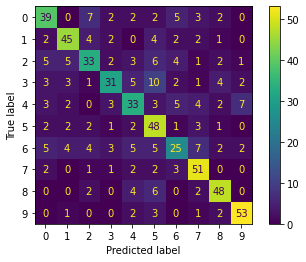

In [25]:
import pandas as pd
from numpy import mean
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.multiclass import OneVsRestClassifier

# Load and preprocess data
X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
X_test = pd.read_csv('Datasets/cleaned_X_test2.csv')
y_test = pd.read_csv('Datasets/y_test.csv')

y_train = y_train.idxmax(axis=1)
y_test = y_test.idxmax(axis=1)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance dataset with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train_encoded)

# Feature selection
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))
X_train_selected = selector.fit_transform(X_train_balanced, y_train_balanced)
X_test_selected = selector.transform(X_test_scaled)

# Hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'saga'],  
    'penalty': ['l2', 'elasticnet'],  
    'max_iter': [100, 200, 500, 1000]
}

logreg = LogisticRegression()
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_selected, y_train_balanced)

# Train best model
best_model = OneVsRestClassifier(grid_search.best_estimator_)
best_model.fit(X_train_selected, y_train_balanced)

# Evaluate train
y_train_pred = best_model.predict(X_train_selected)
print(classification_report(y_train_balanced, y_train_pred))
ConfusionMatrixDisplay.from_predictions(y_train_balanced, y_train_pred)
print(f"Train Accuracy: {accuracy_score(y_train_balanced, y_train_pred):.3f}")


# cross-validation
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
cross_val_scores = cross_val_score(best_model, X_train_selected, y_train_balanced, cv=cv, scoring='accuracy', n_jobs=-1)

# cross-validation printen
print(f"Cross-Validation Accuracy: {mean(cross_val_scores):.3f}")


###overfitting, look at accuaracy, still need some fixed